In [71]:
import numpy as np
import os, glob, json
import acor
import pickle

import enterprise
from enterprise.pulsar import Pulsar
import libstempo as LT
import libstempo.toasim as LTsim

import sys

sys.path.insert(0, "./")
import discovery_new as ds

import matplotlib.pyplot as plt
import scipy

In [4]:
import os
path = './data/DR2low_feathers/'
s_dsfiles = np.sort(os.listdir(path))
d_psrs = [ds.pulsar.Pulsar.read_feather(path + f'{psrfile}') for psrfile in s_dsfiles]

path = './DR2new+_feathers/'
s_dsfiles = np.sort(os.listdir(path))
d_psrs_new = [ds.pulsar.Pulsar.read_feather(path + f'{psrfile}') for psrfile in s_dsfiles]

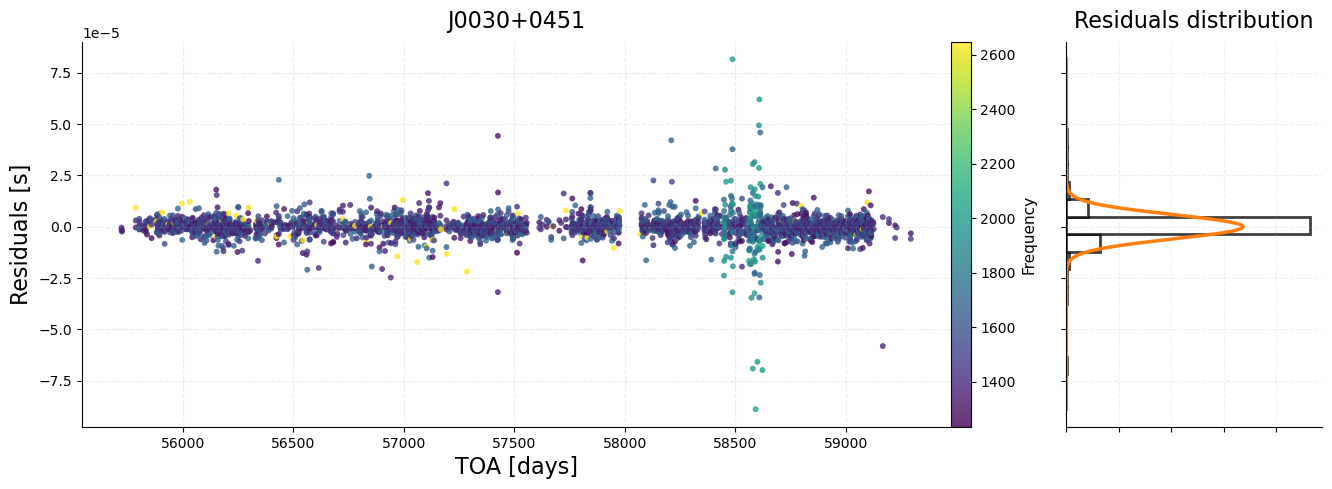

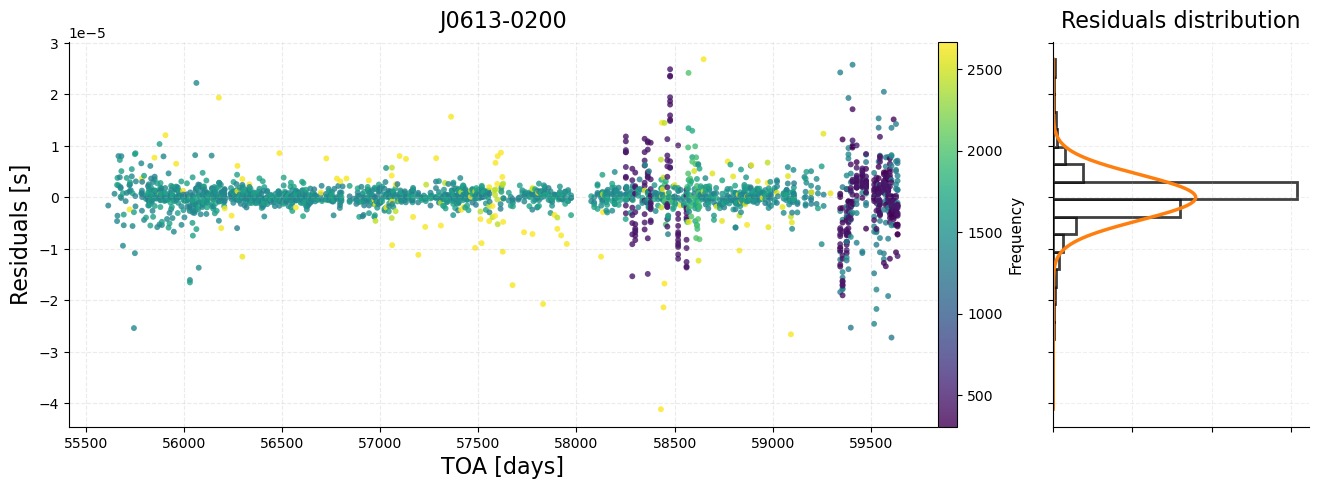

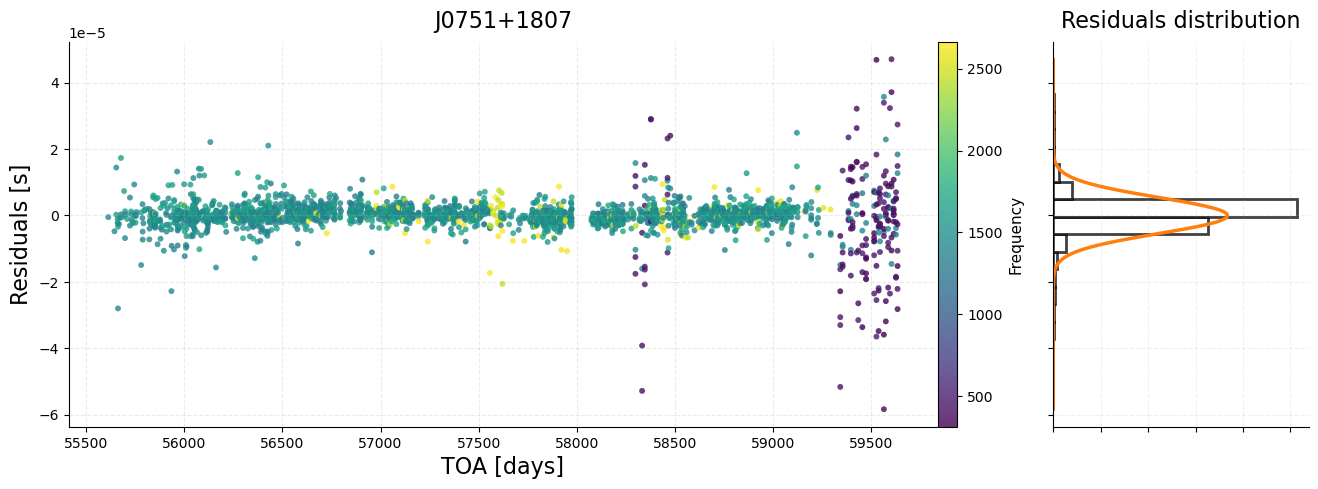

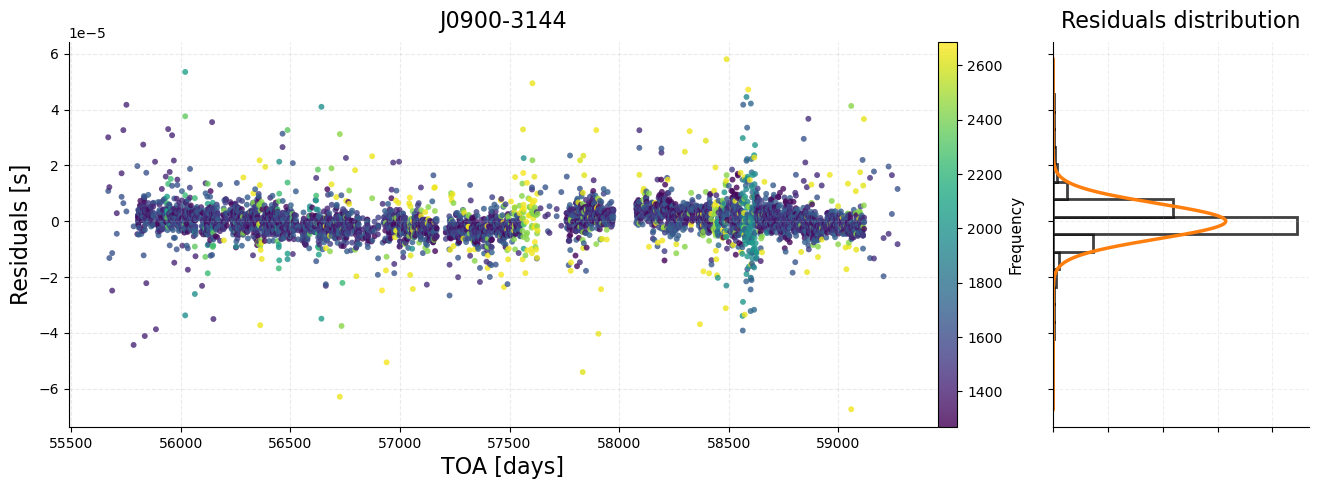

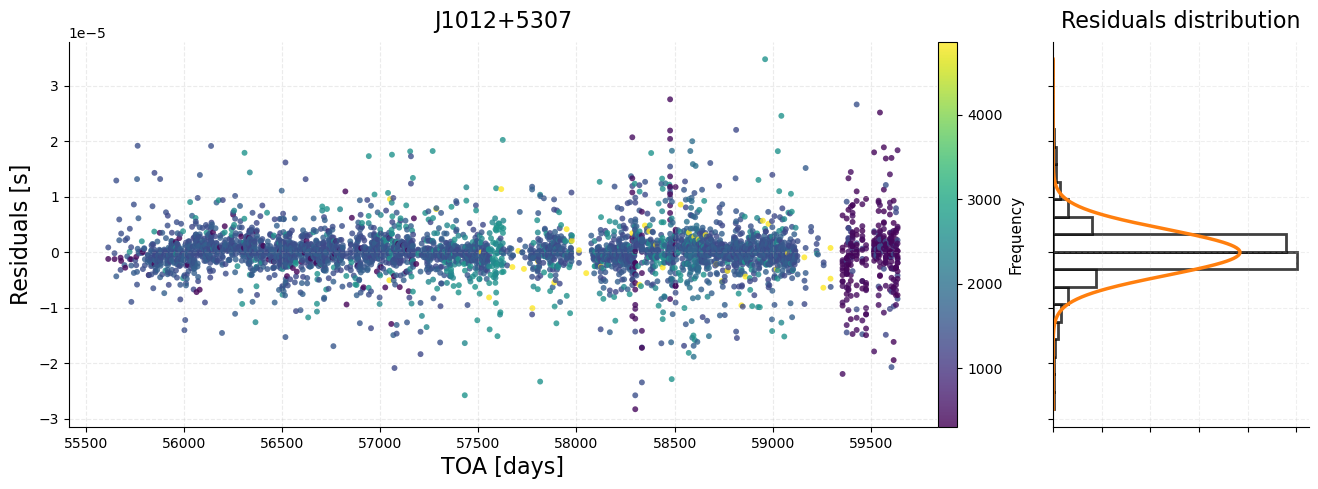

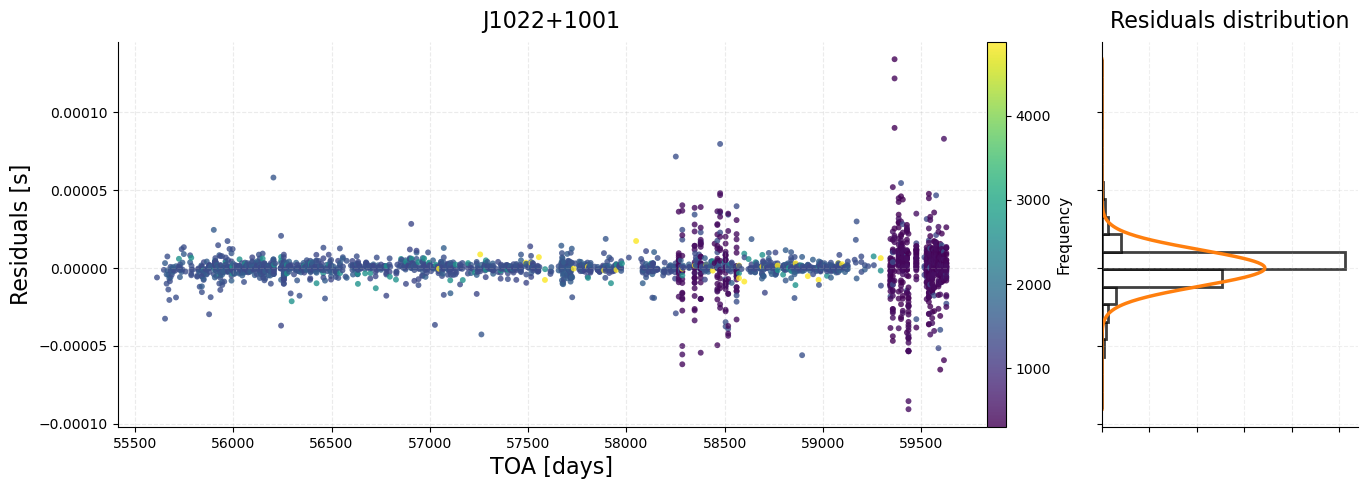

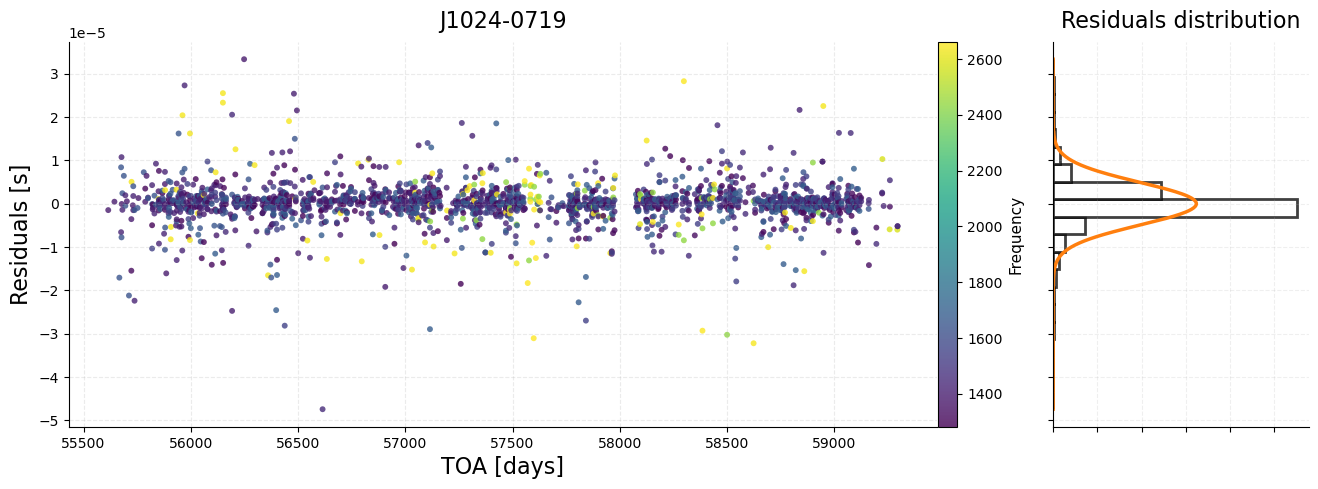

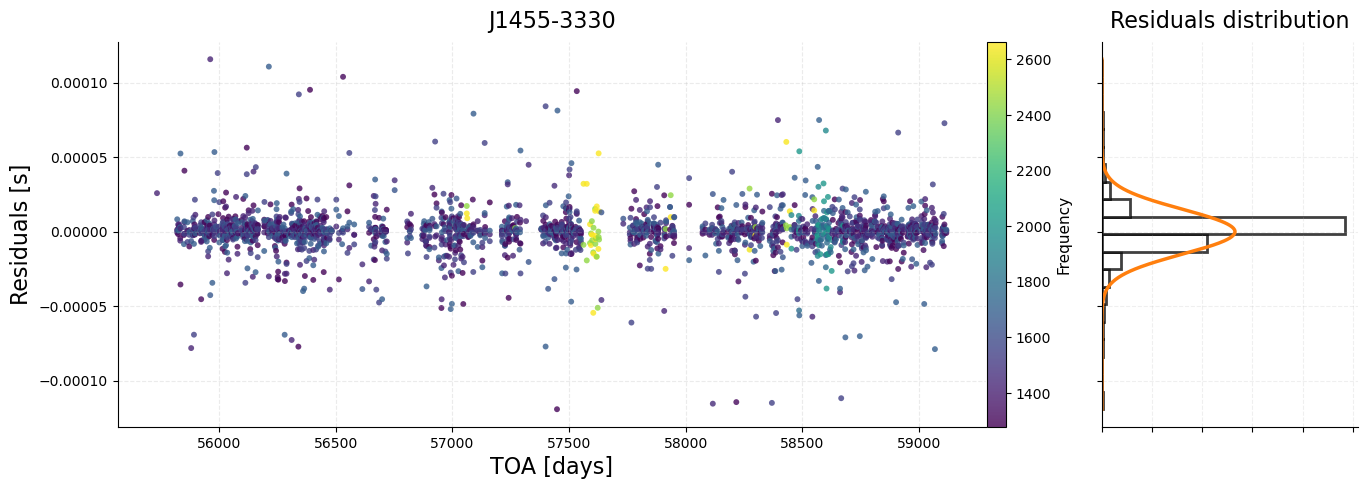

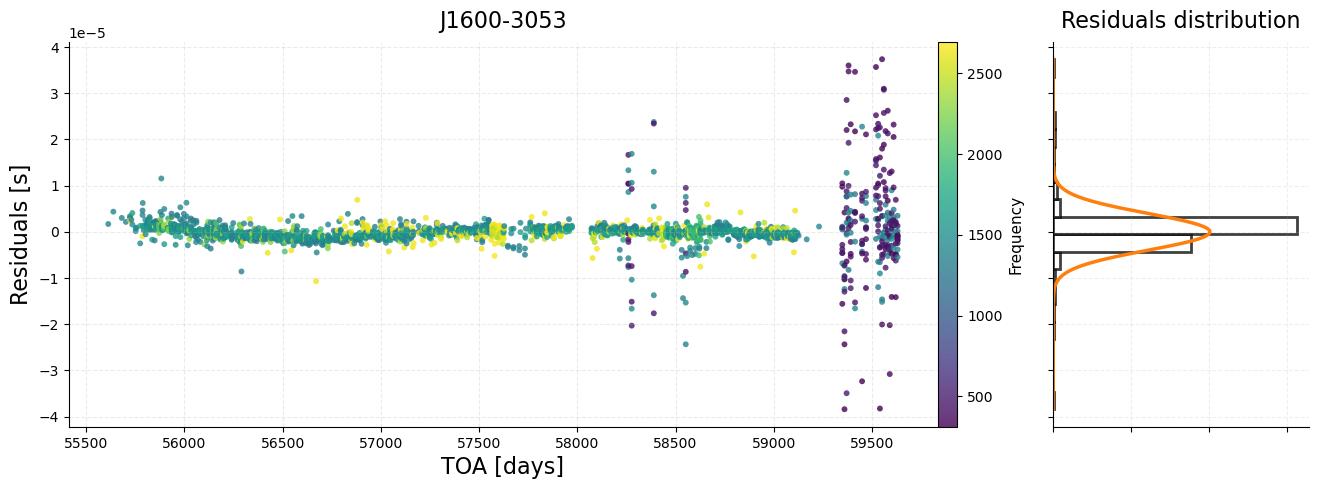

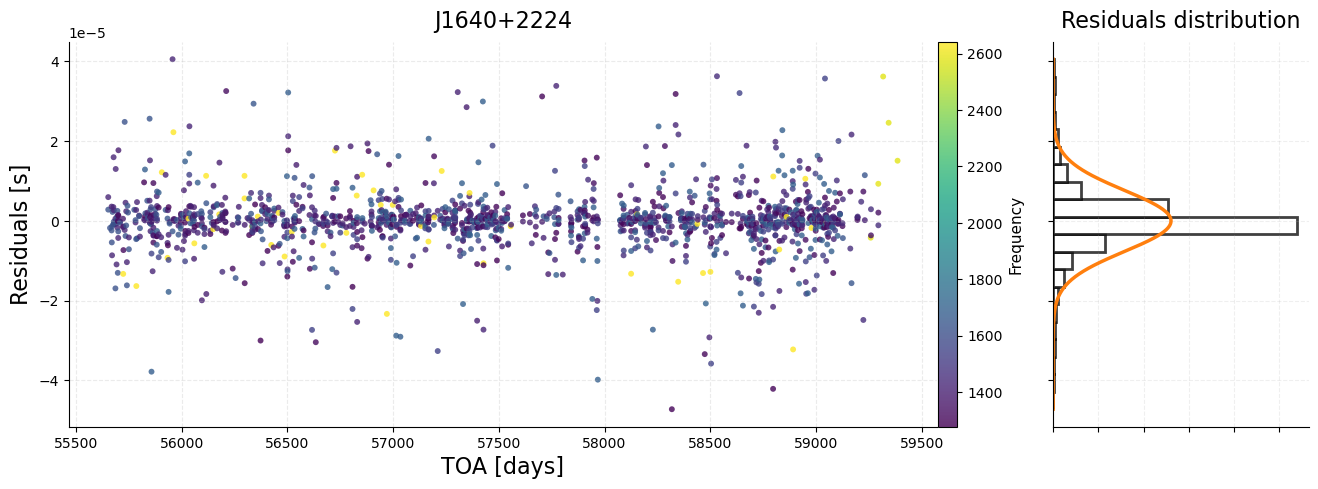

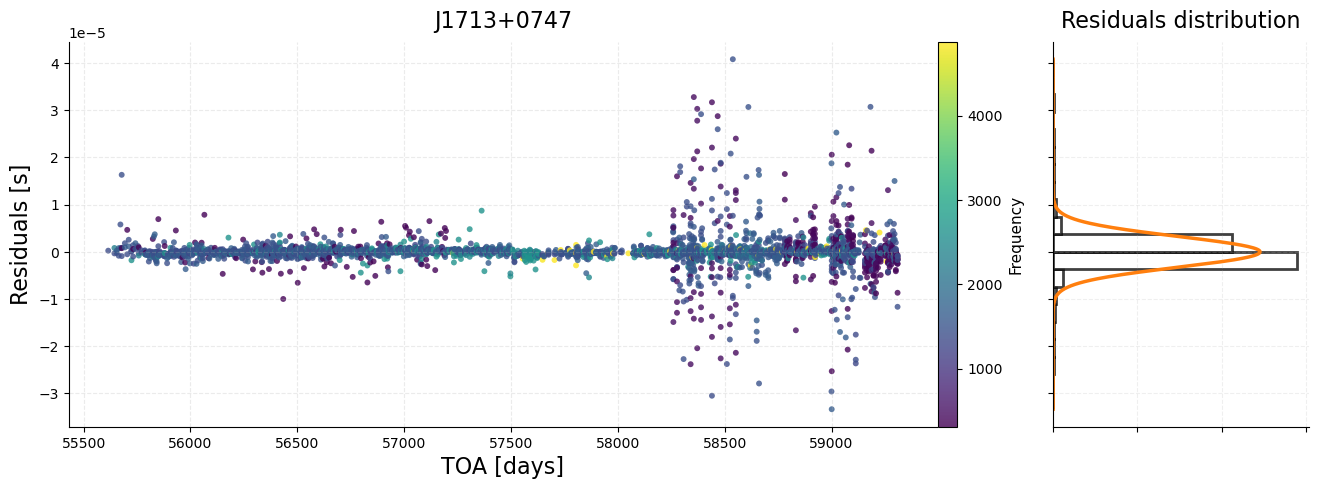

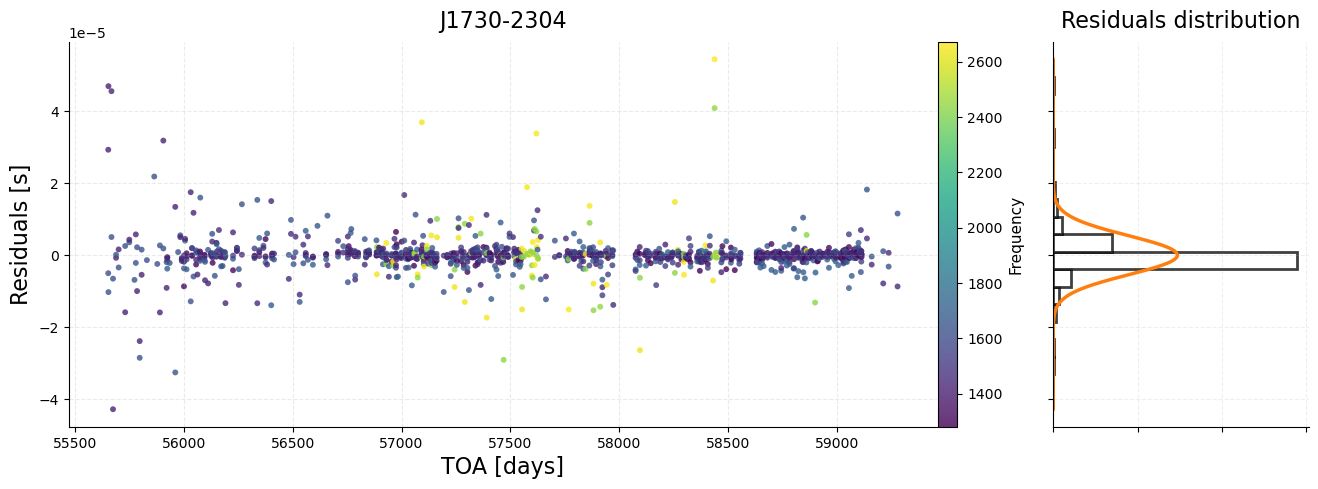

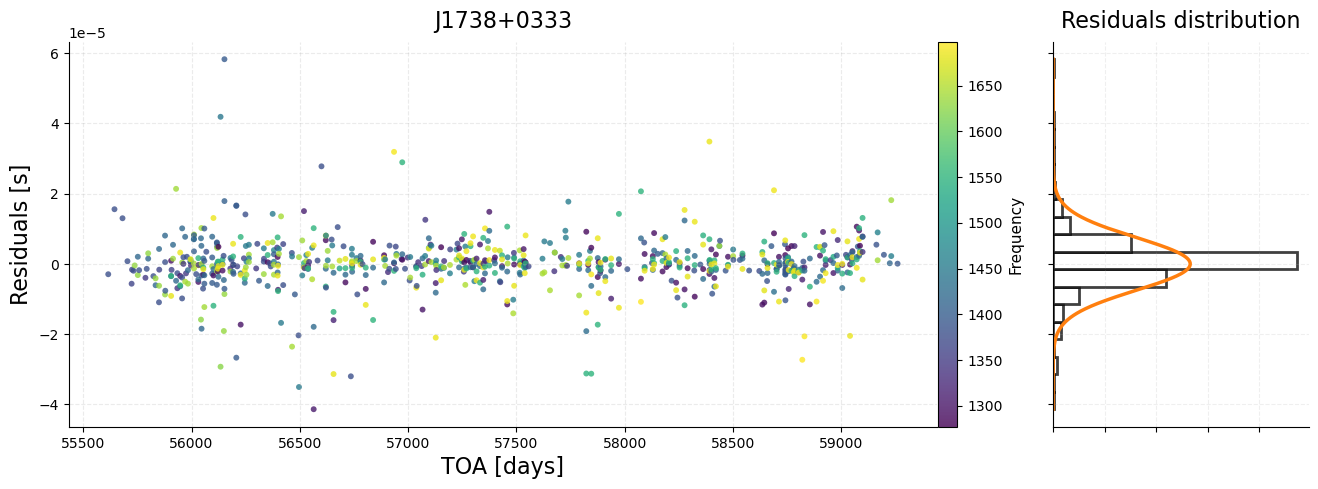

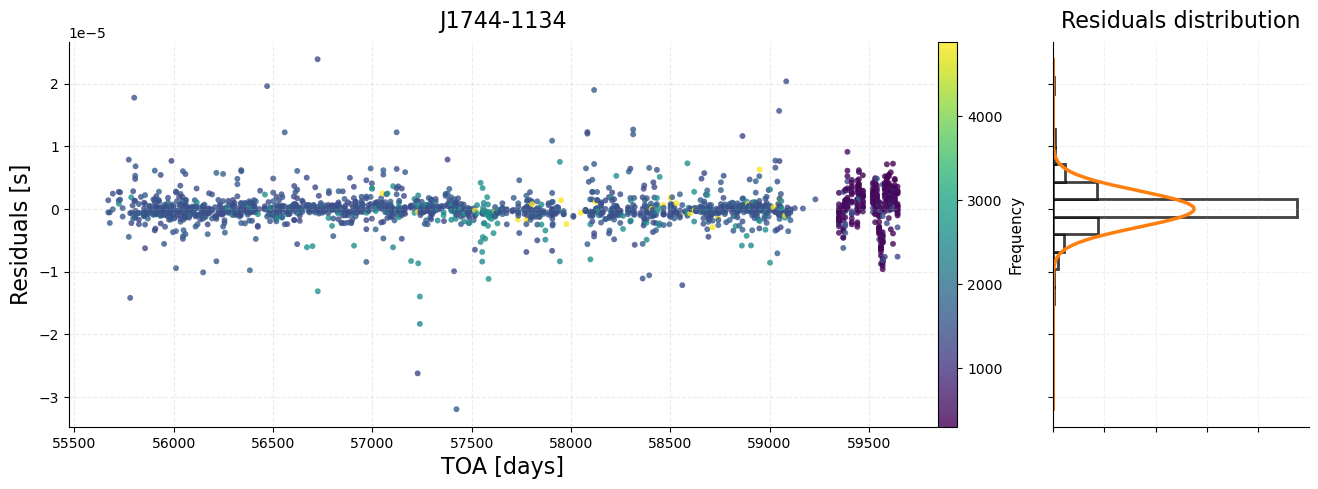

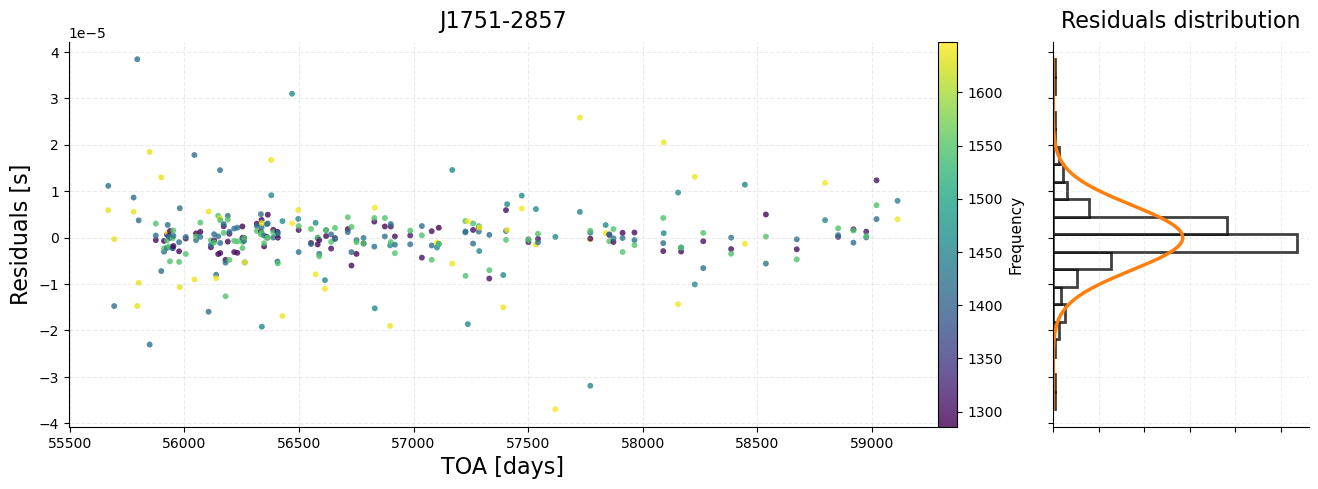

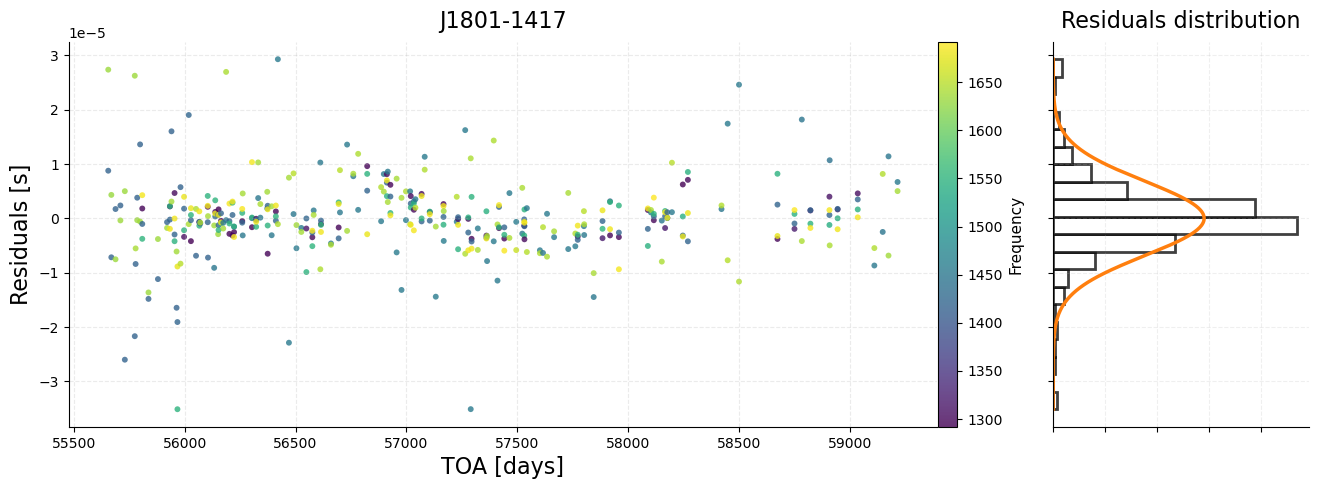

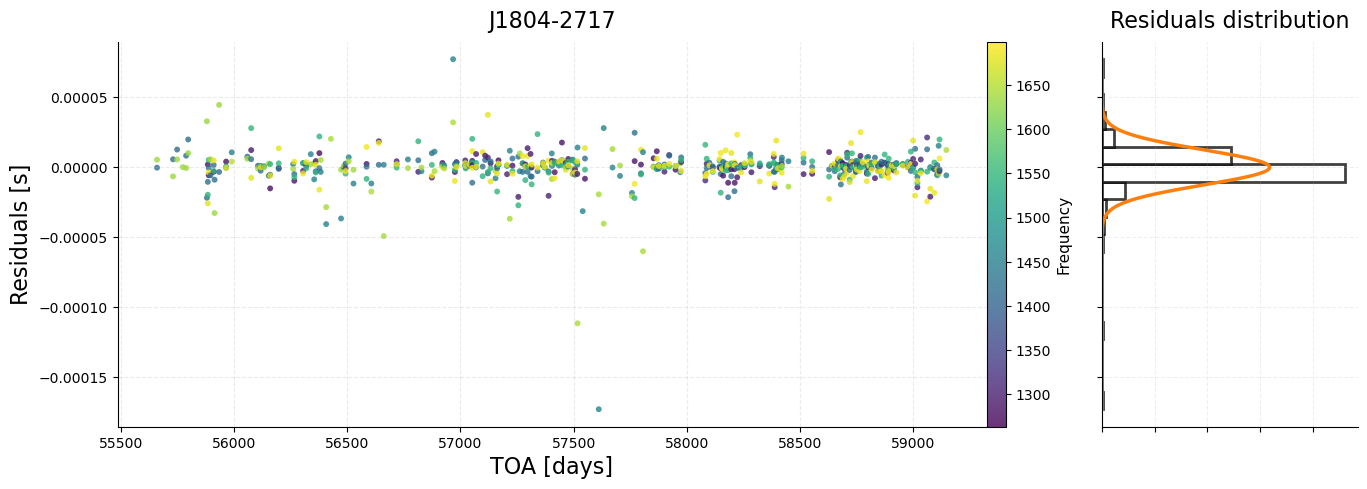

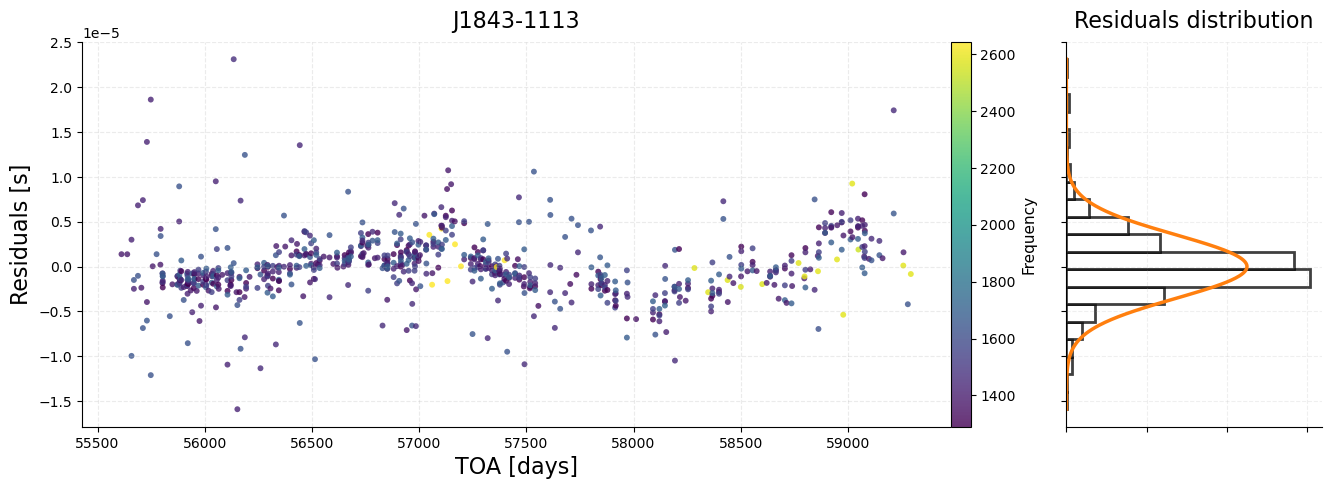

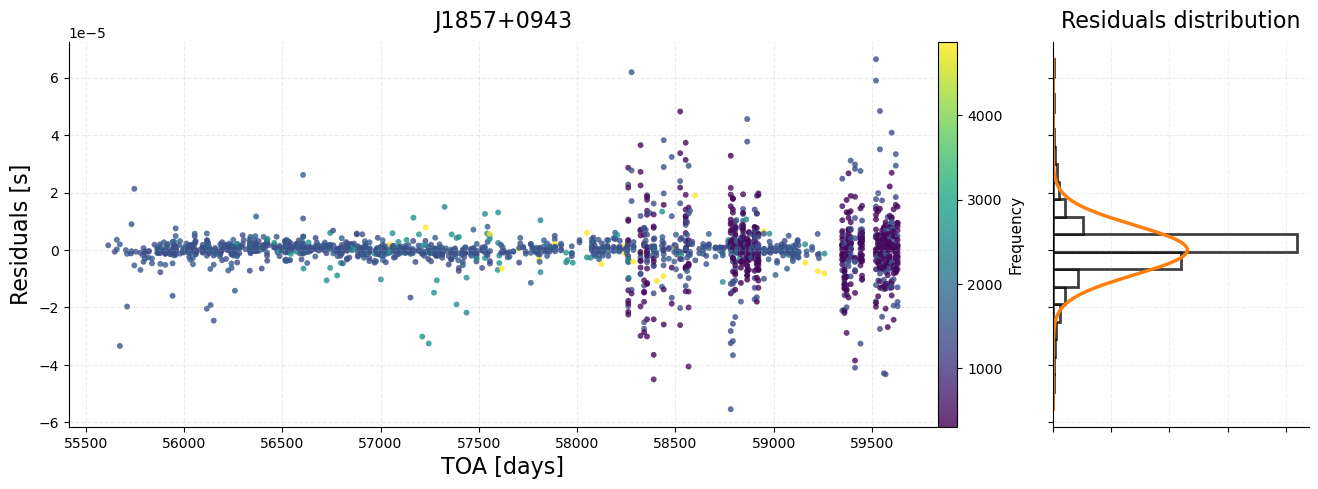

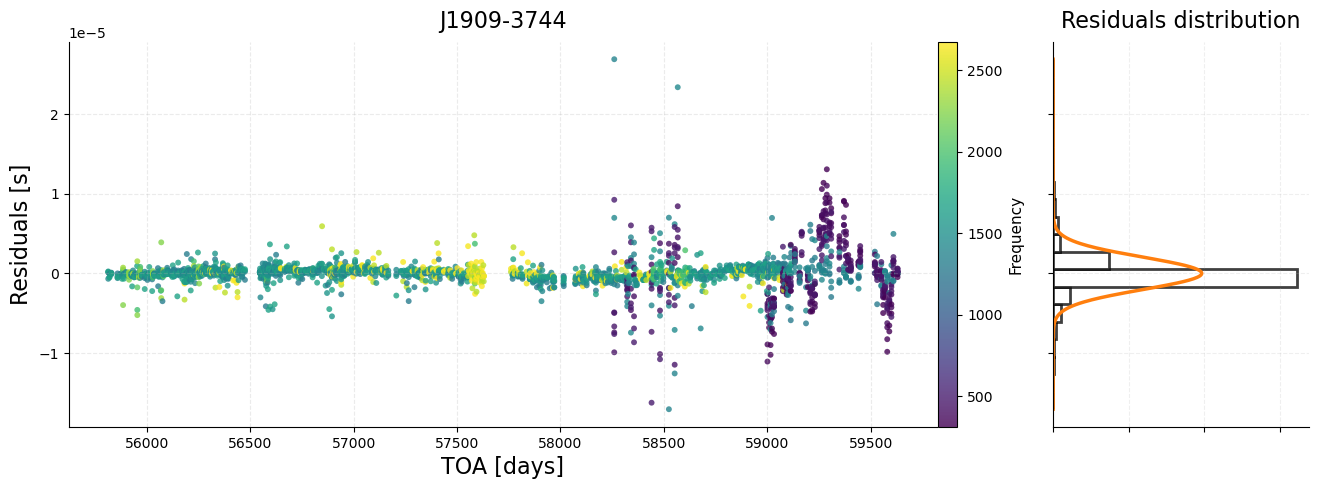

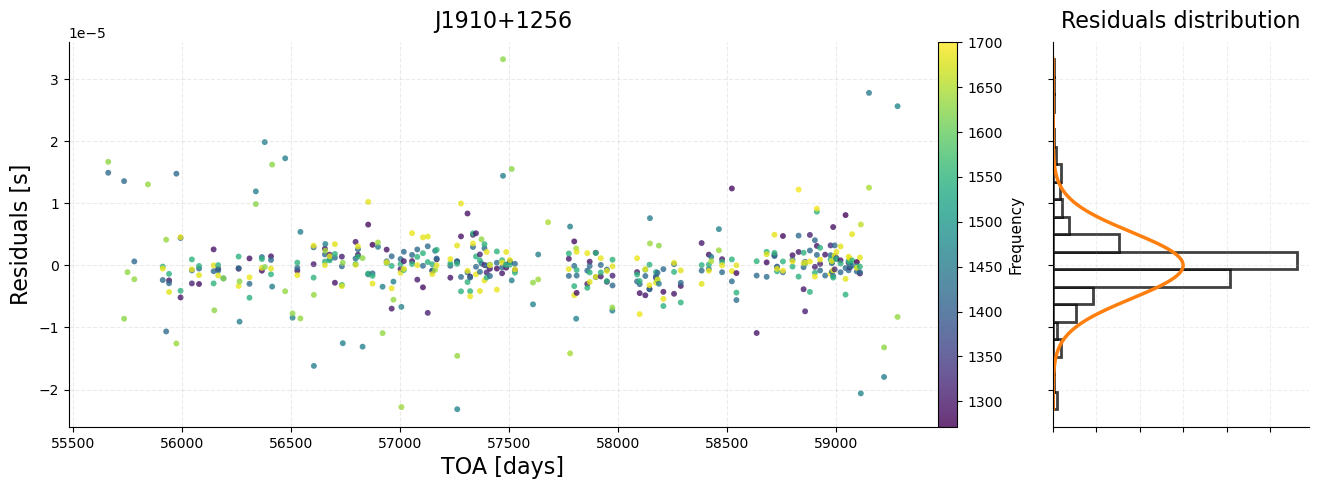

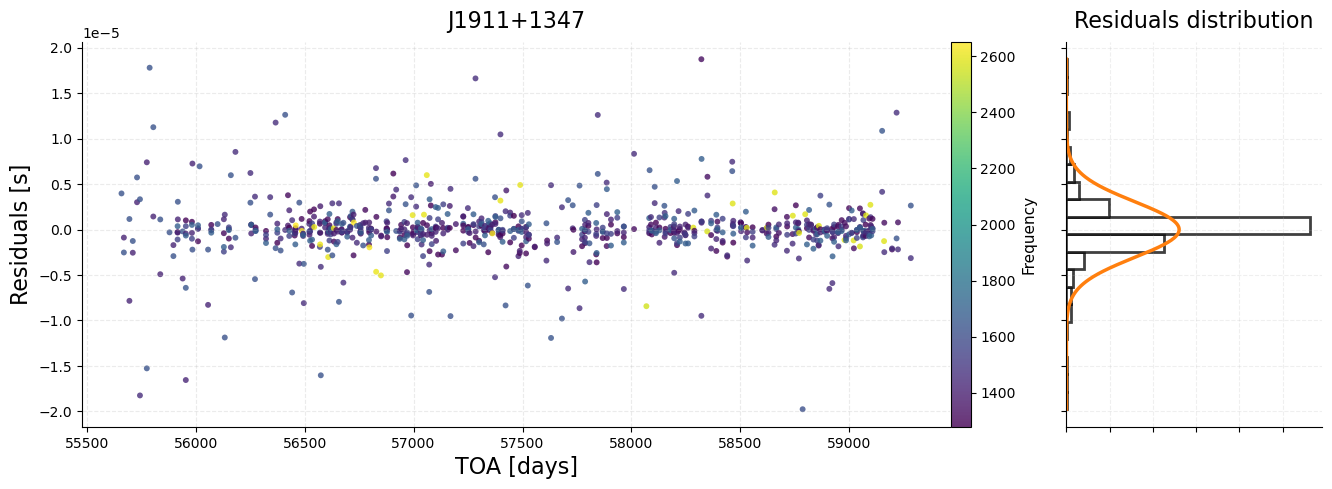

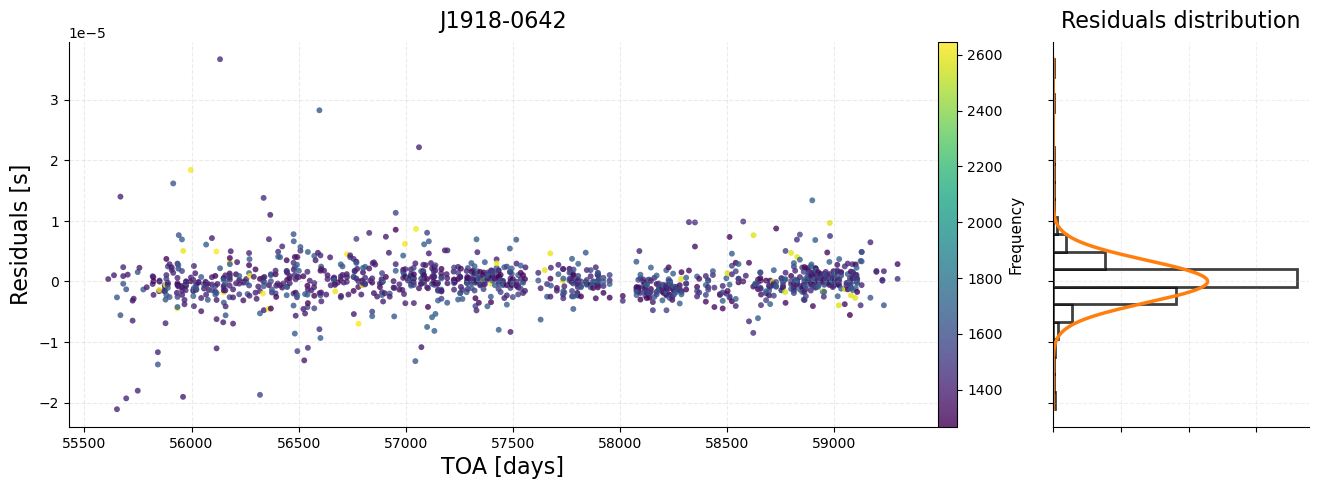

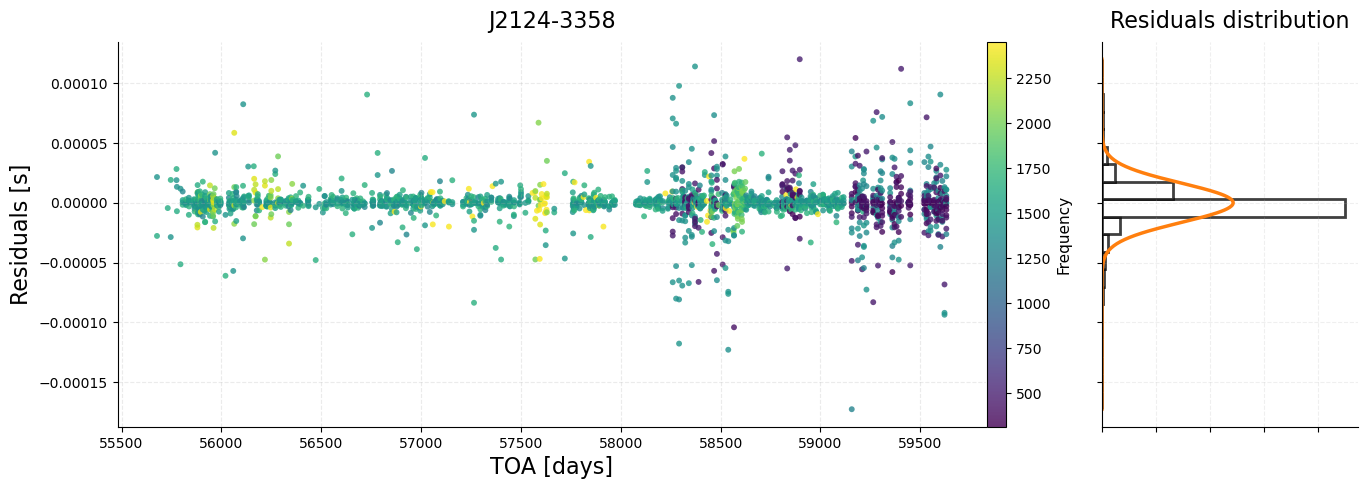

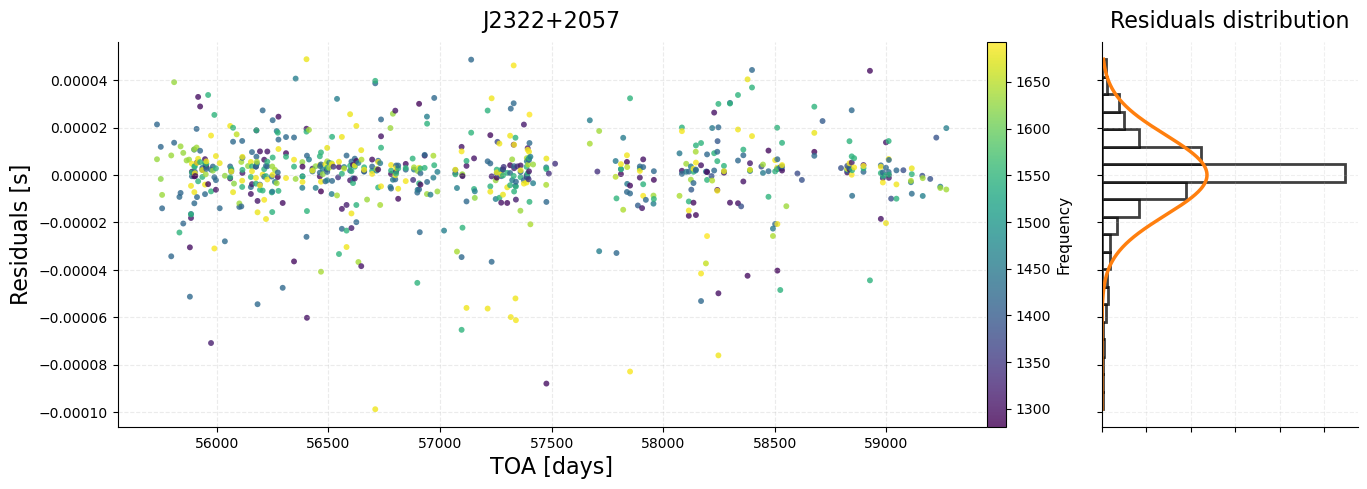

In [77]:
for psr in d_psrs_new:    
    fig, ax = plt.subplots(
        1, 2,
        figsize=(16, 5),
        gridspec_kw={'width_ratios': [4, 1]},
        sharey=True
    )
    
    sc = ax[0].scatter(psr.toas / 86400, psr.residuals, c=psr.freqs, s=18, alpha=0.8, cmap='viridis', edgecolors='none')
    
    ax[0].set_xlabel("TOA [days]", fontsize=16)
    ax[0].set_ylabel("Residuals [s]", fontsize=16)
    ax[0].set_title(psr.name, fontsize=16, pad=10)
    

    ax[0].grid(alpha=0.25, linestyle='--')
    ax[0].spines['top'].set_visible(False)
    ax[0].spines['right'].set_visible(False)
    
    ax[1].hist(psr.residuals, bins=20, orientation='horizontal', color='w', alpha=0.75, edgecolor='black', linewidth=2, density=True)

    mu, sigma = np.mean(psr.residuals), np.std(psr.residuals)

    y = np.linspace(psr.residuals.min(), psr.residuals.max(), 500)
    pdf = scipy.stats.norm.pdf(y, mu, sigma)
    
    # Overlay Gaussian
    ax[1].plot(pdf, y, color='tab:orange', linewidth=2.5, label=fr'$\mu={mu:.2e}$' + '\n' + fr'$\sigma={sigma:.2e}$')

    ax[1].set_title("Residuals distribution", fontsize=16, pad=10)
    ax[1].grid(alpha=0.2, linestyle='--')
    

    ax[1].tick_params(axis='y', labelleft=False)
    ax[1].tick_params(axis='x', right=False, labelbottom=False)
    
    ax[1].spines['top'].set_visible(False)
    ax[1].spines['right'].set_visible(False)

    cbar = fig.colorbar(sc, ax=ax[0], pad=0.001)
    cbar.set_label("Frequency", fontsize=11)
    

    fig.subplots_adjust(wspace=-0.06)
    
    plt.show()

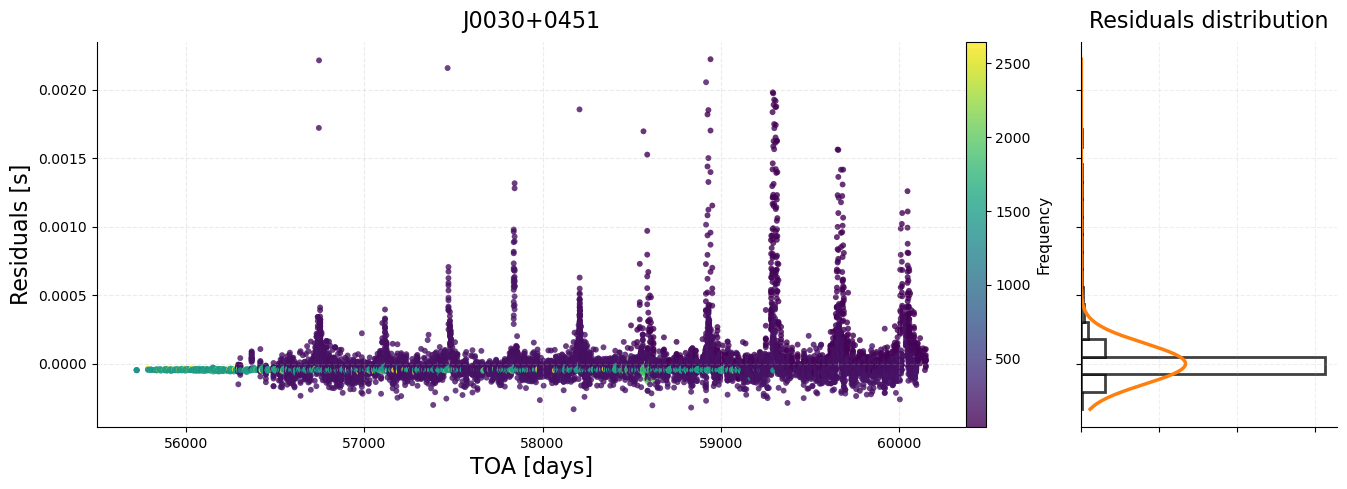

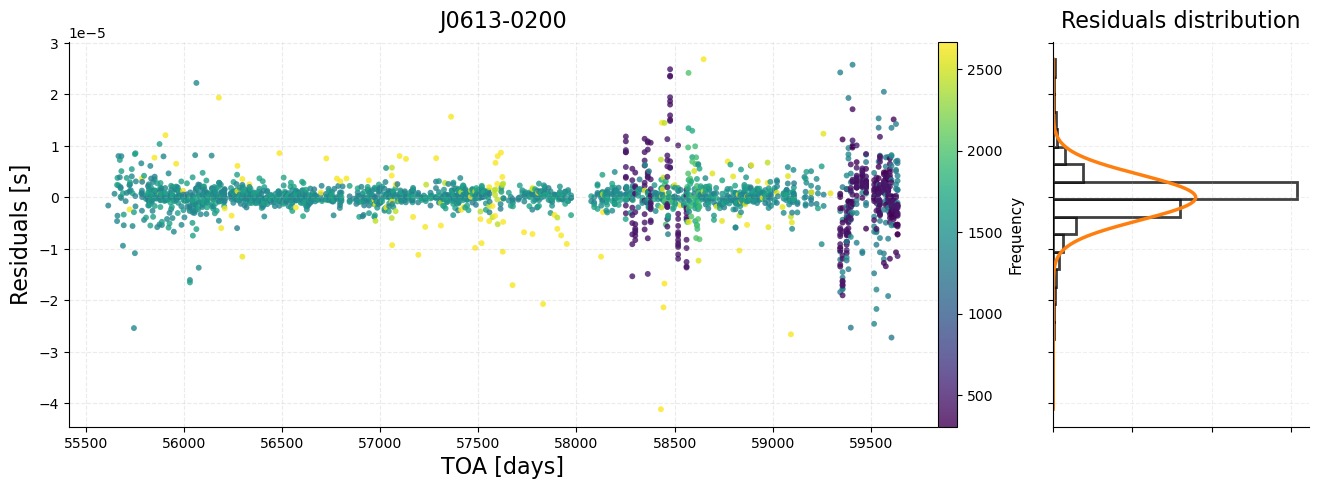

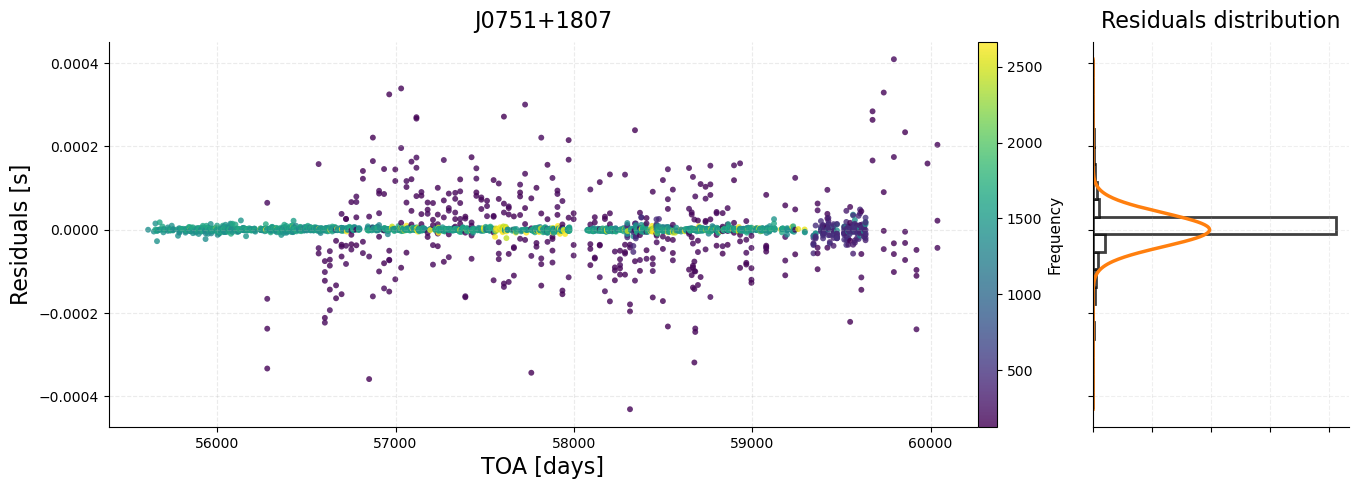

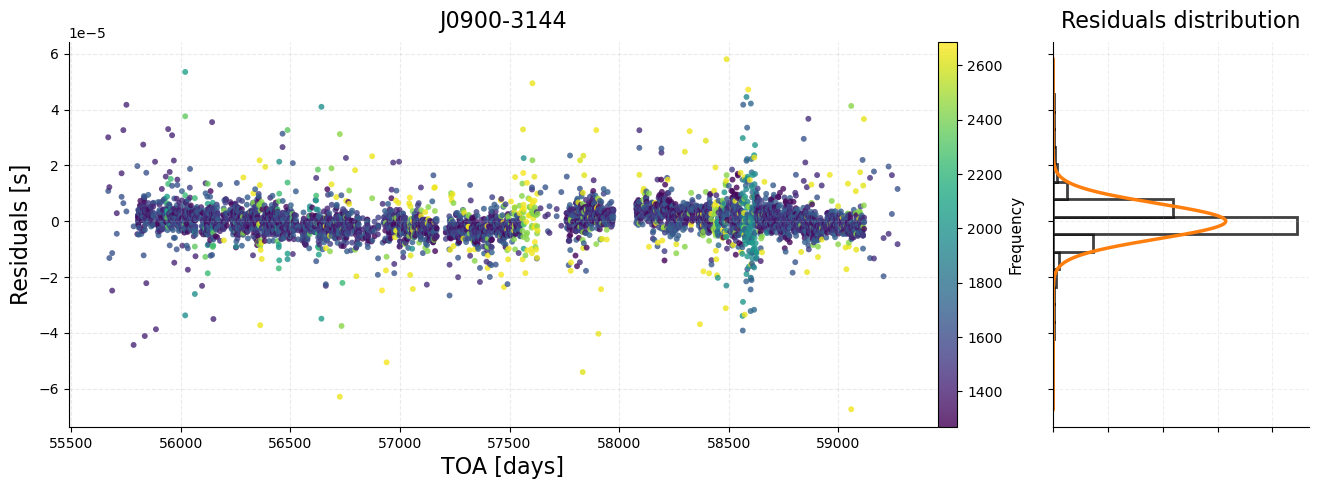

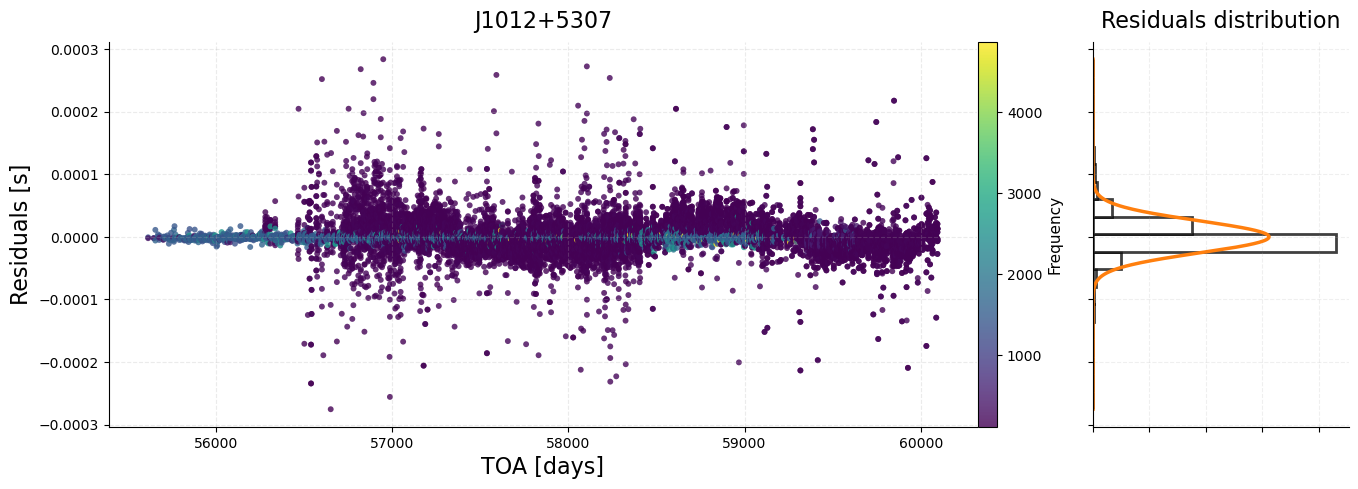

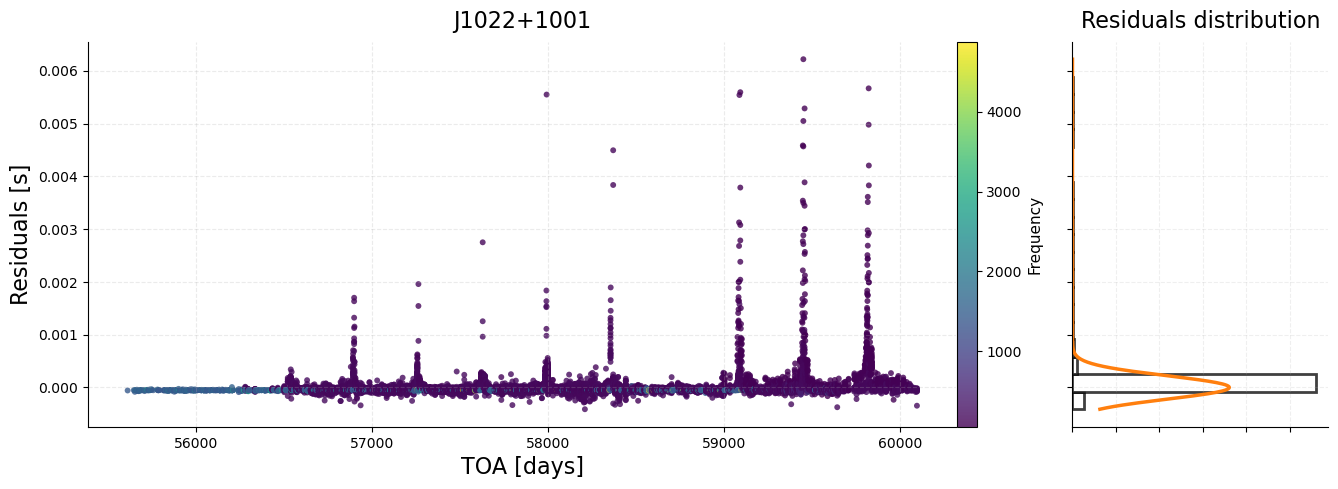

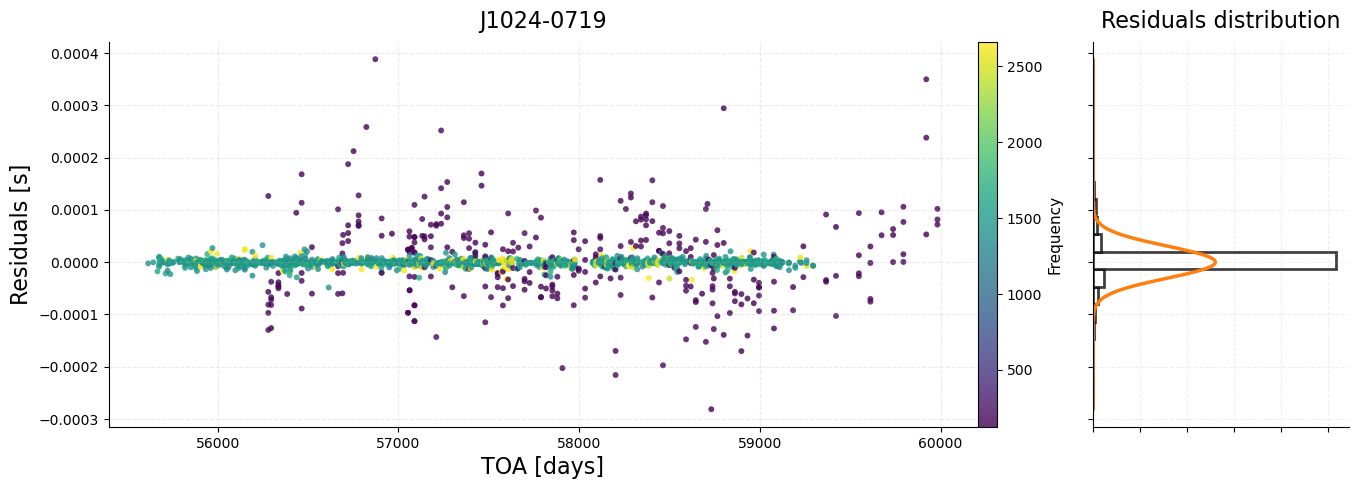

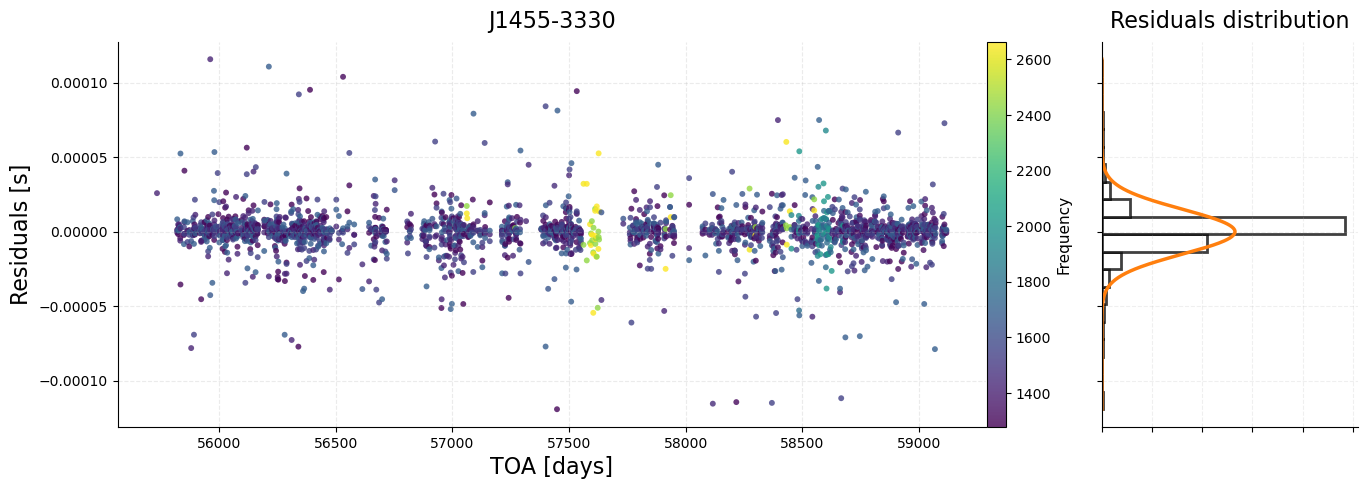

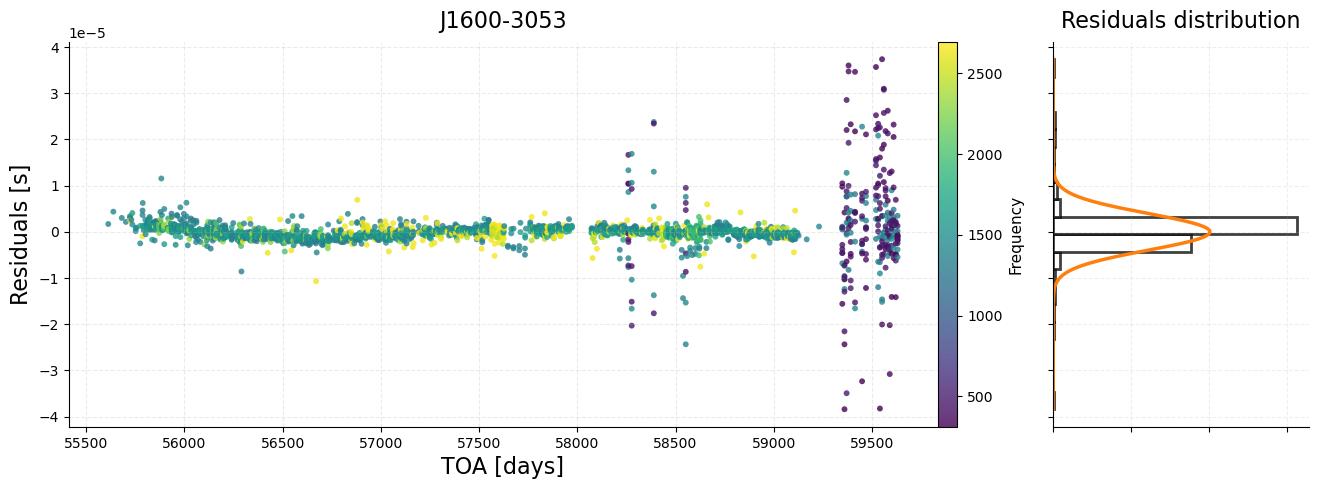

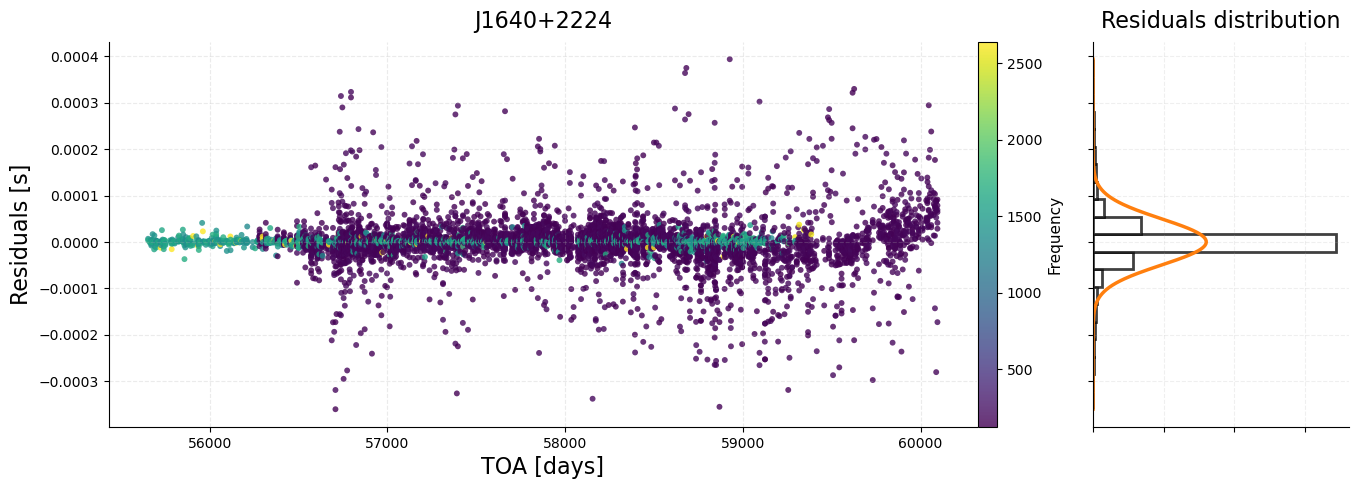

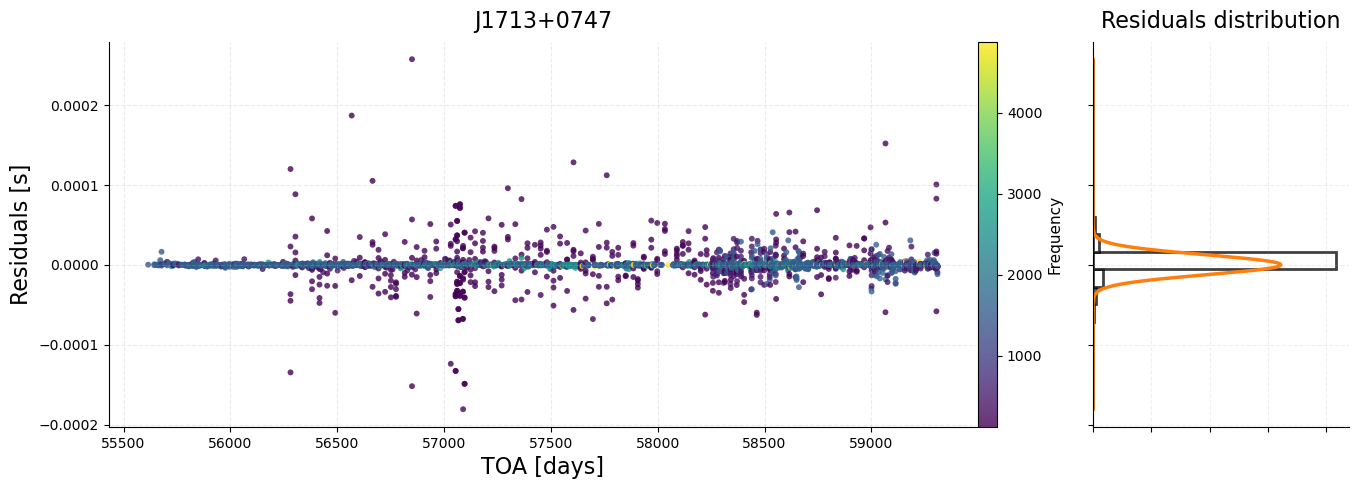

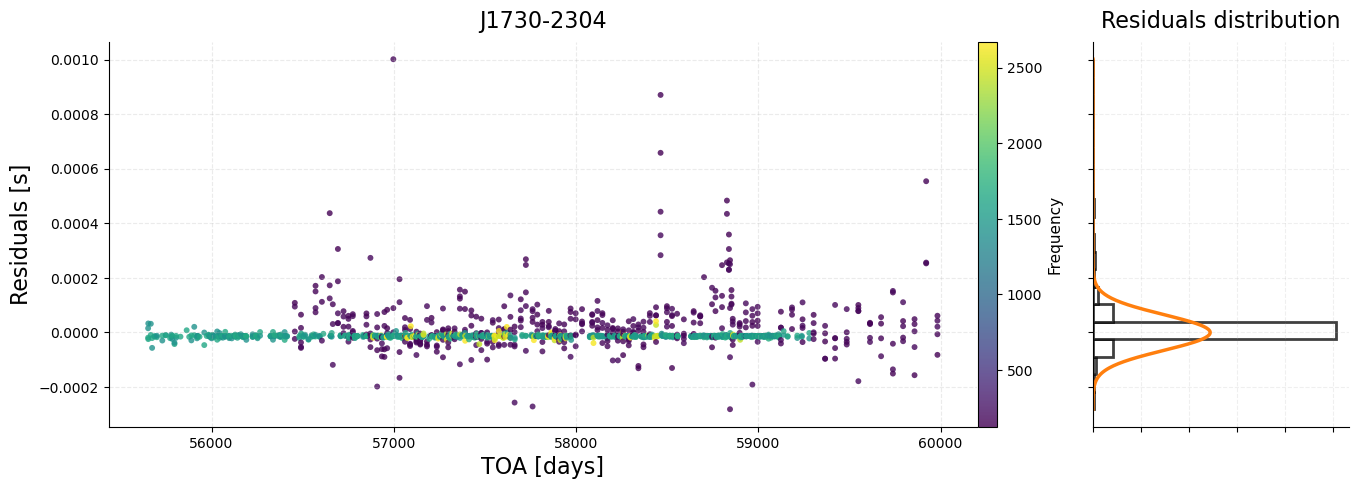

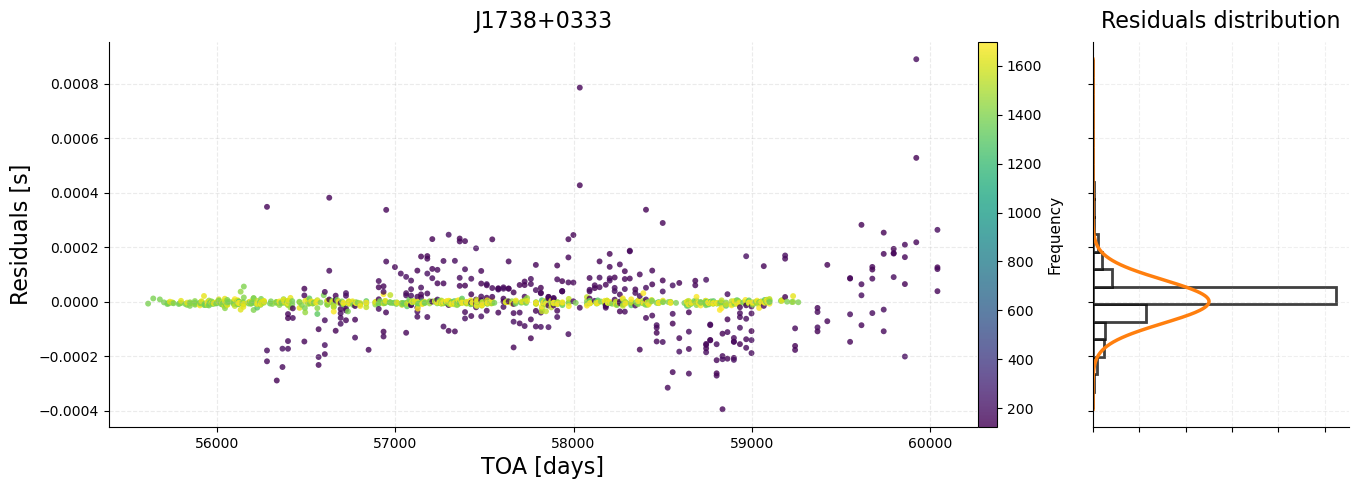

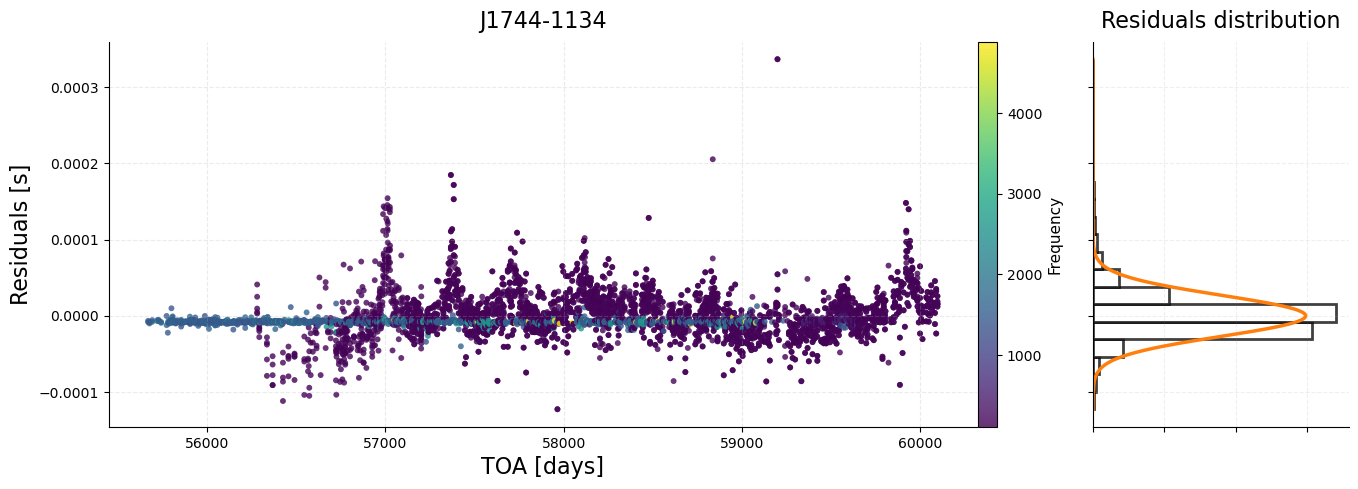

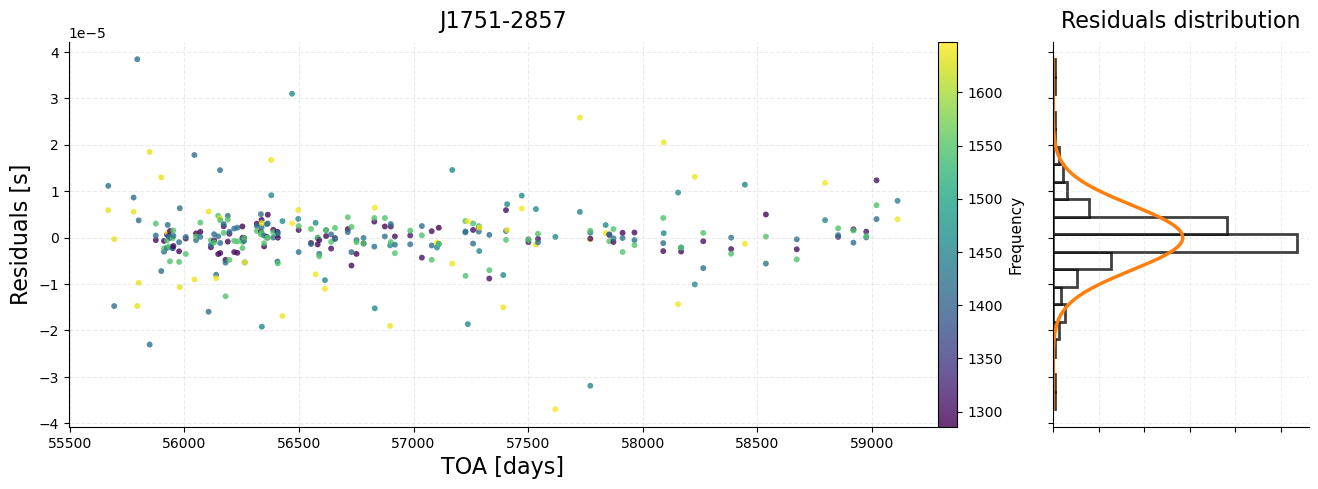

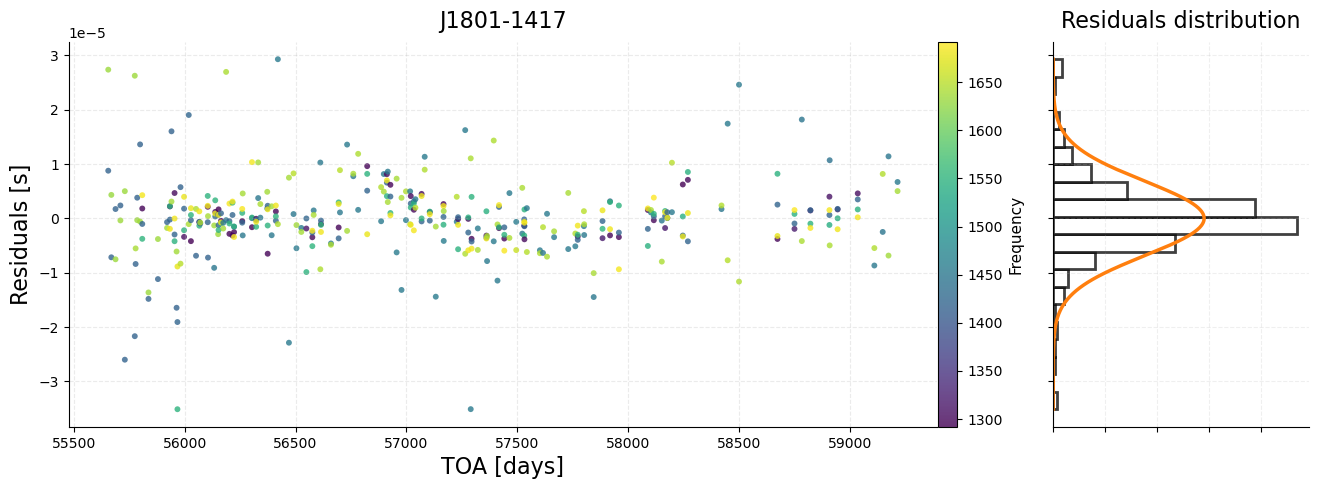

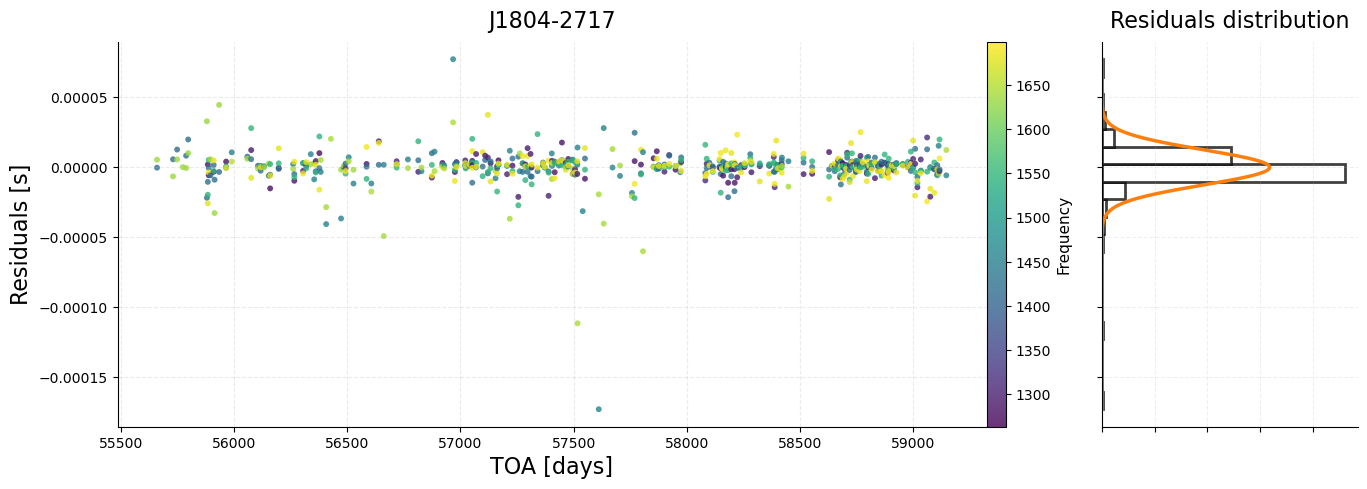

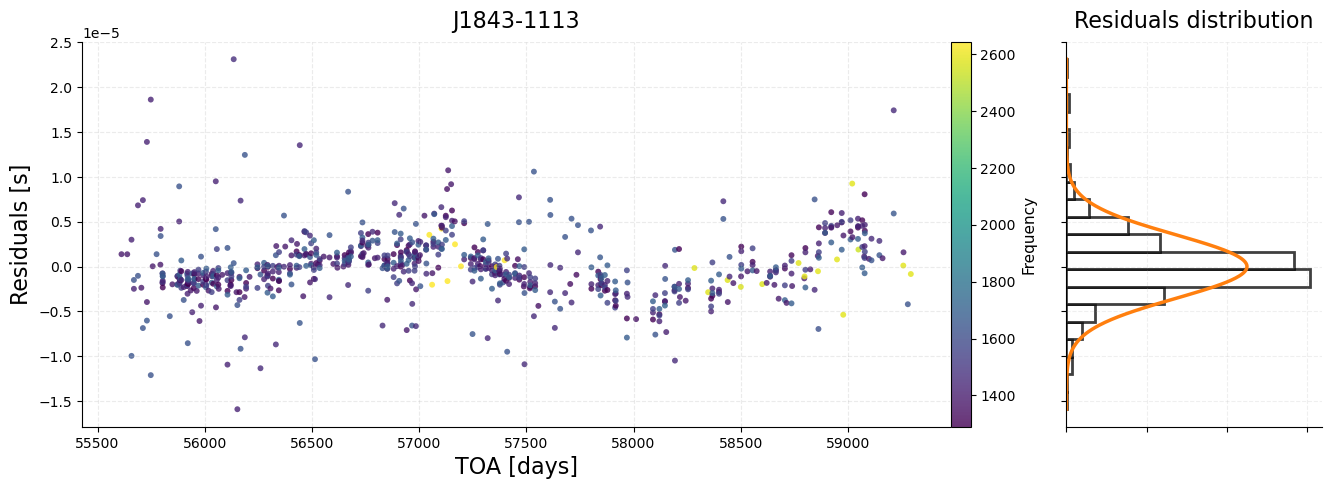

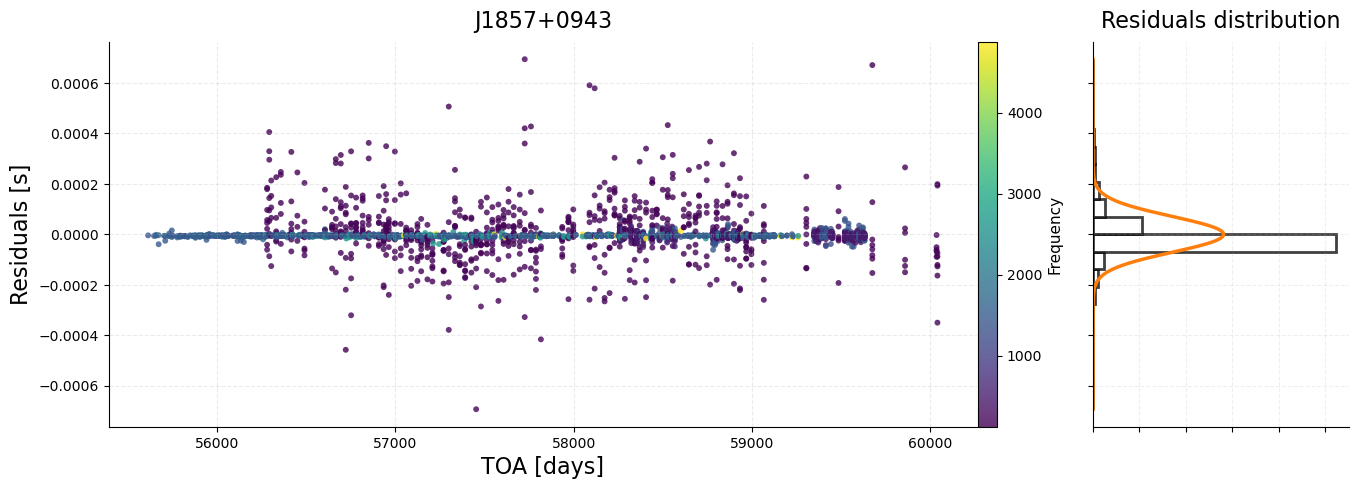

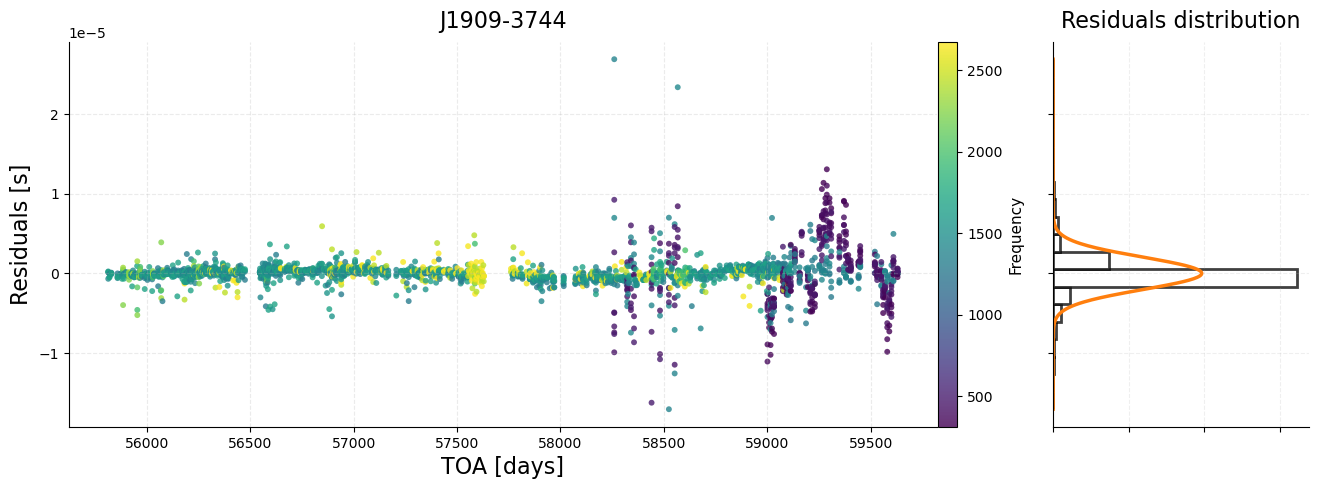

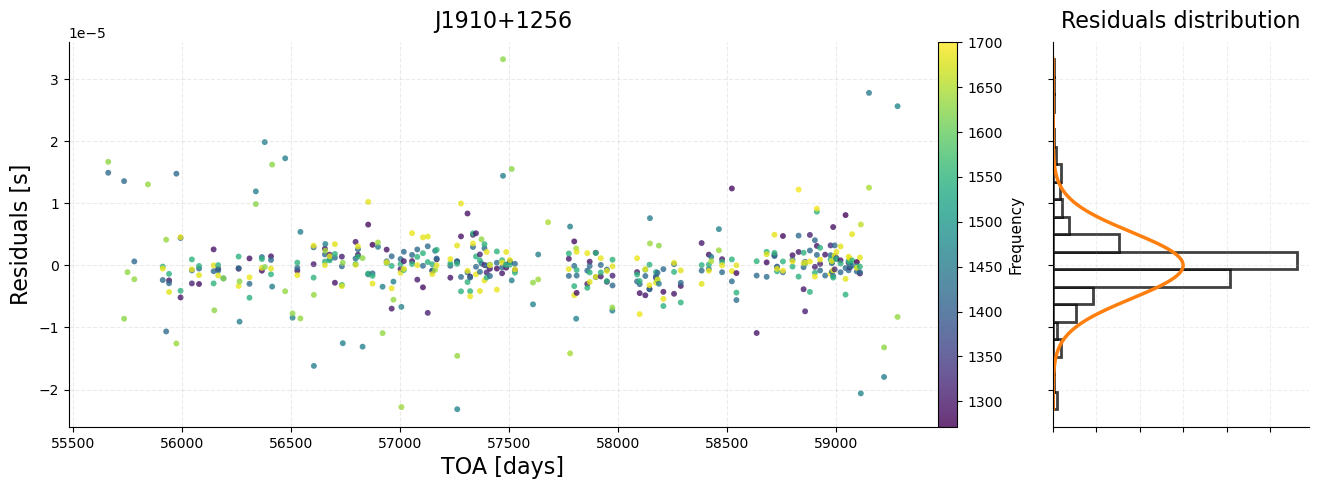

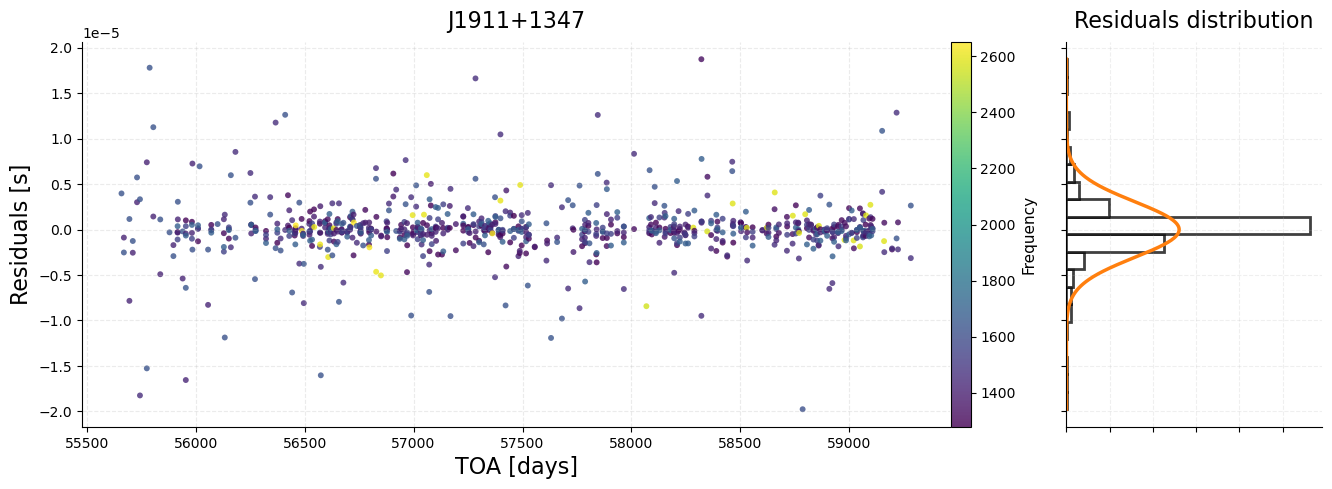

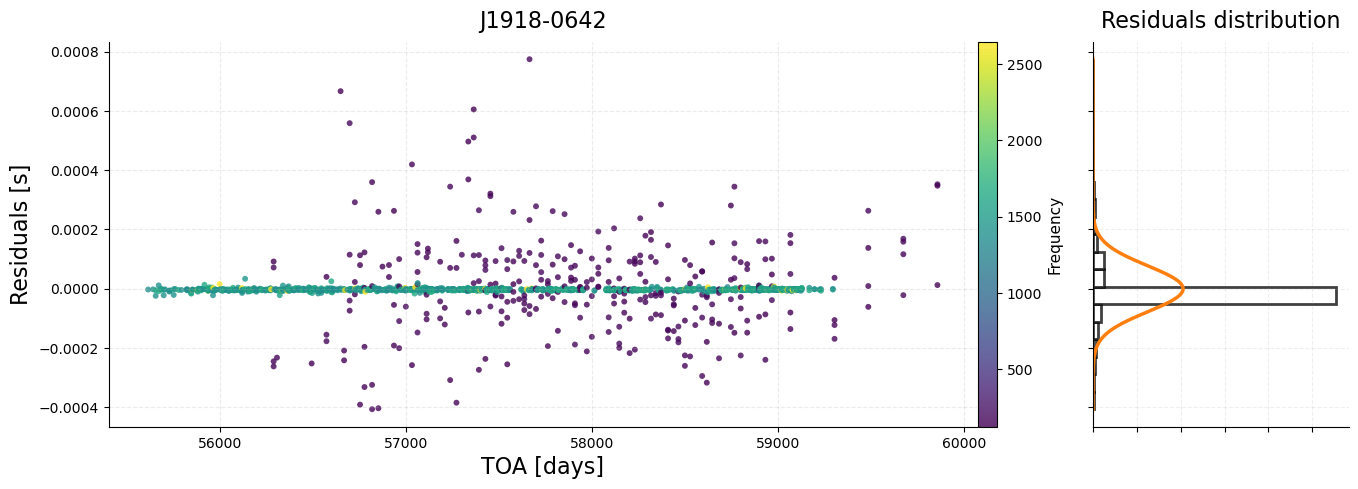

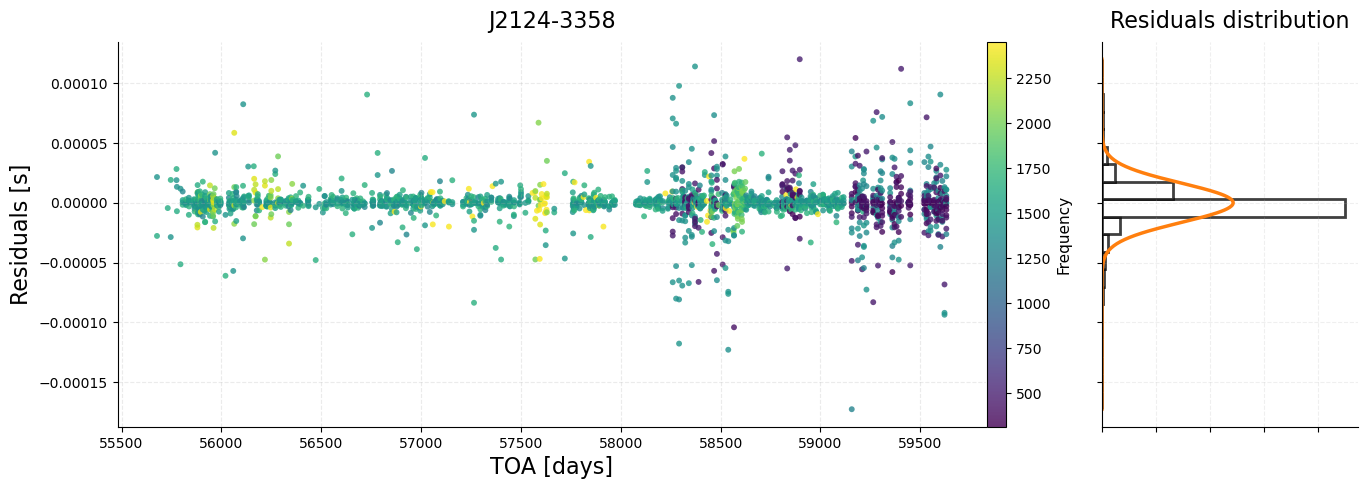

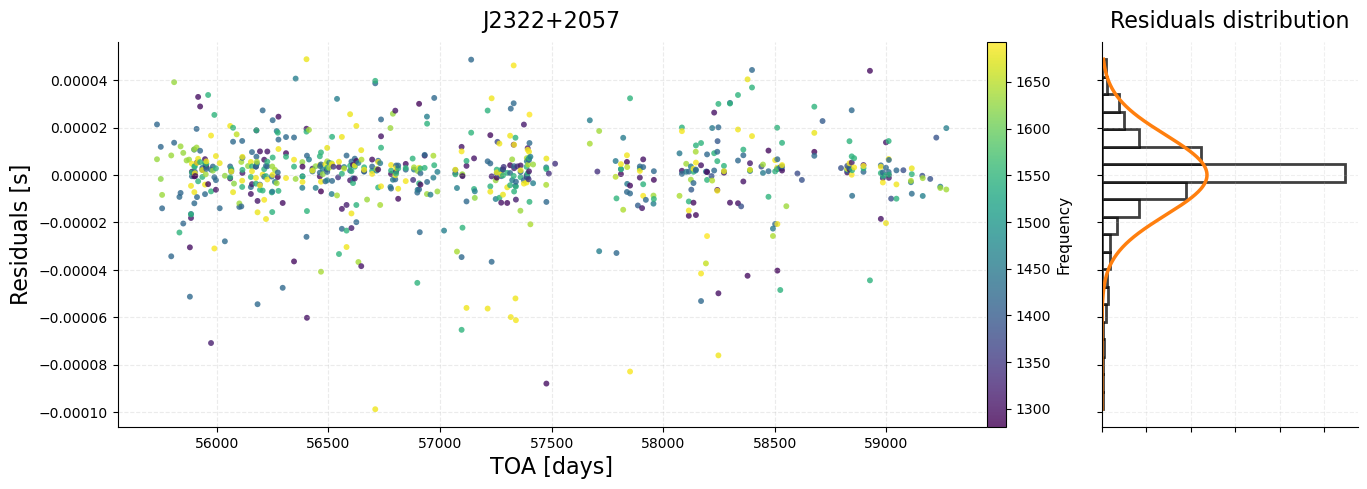

In [76]:
for psr in d_psrs:    
    fig, ax = plt.subplots(
        1, 2,
        figsize=(16, 5),
        gridspec_kw={'width_ratios': [4, 1]},
        sharey=True
    )
    
    sc = ax[0].scatter(psr.toas / 86400, psr.residuals, c=psr.freqs, s=18, alpha=0.8, cmap='viridis', edgecolors='none')
    
    ax[0].set_xlabel("TOA [days]", fontsize=16)
    ax[0].set_ylabel("Residuals [s]", fontsize=16)
    ax[0].set_title(psr.name, fontsize=16, pad=10)
    

    ax[0].grid(alpha=0.25, linestyle='--')
    ax[0].spines['top'].set_visible(False)
    ax[0].spines['right'].set_visible(False)
    
    ax[1].hist(psr.residuals, bins=20, orientation='horizontal', color='w', alpha=0.75, edgecolor='black', linewidth=2, density=True)

    mu, sigma = np.mean(psr.residuals), np.std(psr.residuals)

    y = np.linspace(psr.residuals.min(), psr.residuals.max(), 500)
    pdf = scipy.stats.norm.pdf(y, mu, sigma)
    
    # Overlay Gaussian
    ax[1].plot(pdf, y, color='tab:orange', linewidth=2.5, label=fr'$\mu={mu:.2e}$' + '\n' + fr'$\sigma={sigma:.2e}$')

    ax[1].set_title("Residuals distribution", fontsize=16, pad=10)
    ax[1].grid(alpha=0.2, linestyle='--')
    

    ax[1].tick_params(axis='y', labelleft=False)
    ax[1].tick_params(axis='x', right=False, labelbottom=False)
    
    ax[1].spines['top'].set_visible(False)
    ax[1].spines['right'].set_visible(False)

    cbar = fig.colorbar(sc, ax=ax[0], pad=0.001)
    cbar.set_label("Frequency", fontsize=11)
    

    fig.subplots_adjust(wspace=-0.06)
    
    plt.show()